In [1]:
import datetime
import pingouin as pg
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
sns.set_theme(context='talk', style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = 10, 7
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['figure.titlesize'] = 32
plt.rcParams['axes.titlesize'] = 32
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['figure.autolayout'] = 'true'
plt.rcParams['figure.frameon'] = 'false'
plt.rcParams['axes.spines.left'] = 'false'
plt.rcParams['axes.spines.right'] = 'false'
plt.rcParams['axes.spines.top'] = 'false'
plt.rcParams['legend.fancybox'] = 'false'
plt.rcParams['axes.spines.bottom'] = 'false'
plt.rcParams['font.size'] = 20
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
# для графиков, где надо много цветов, юзайте воть:
sns.set_palette(sns.color_palette('deep'))
# а по дефолту воть:
sns.set_palette(sns.color_palette('BuGn_r', n_colors=10)[2::3])
pd.set_option('display.max_columns', 60)

monthly_feeding = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Feeding')
herd_metrics = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Herd maintenance').replace('-', np.nan)
production_indicators = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Dairy indicators').replace('-', np.nan)

herd_metrics["year_month"] = herd_metrics["date"].dt.to_period('M').astype(str)

fad = pd.read_csv("datasets//FeedingAndDetails_clear.csv", index_col=0)

fad["Date"] = pd.to_datetime(fad["Date"])
fad["year_month"] = fad["Date"].dt.to_period('M').astype(str)
fad = fad.rename(columns={"FarmName": "farm_name"})


In [2]:
herd_metrics = herd_metrics[~((herd_metrics['calves']==0) & (herd_metrics['cow_metrit']!=0))]

In [3]:
from scipy.stats import skew, kurtosis
import numpy as np

def extract_features_from_window(win_df, ration_cols):
    """
    win_df — DataFrame с окном [T-60, T-1] для одной фермы.
    ration_cols — список колонок с признаками рациона.

    Возвращает dict с фичами:
      <col>_mean, <col>_std, <col>_min, <col>_max,
      <col>_median, <col>_iqr, <col>_skew, <col>_kurtosis, <col>_trend
    """
    features = {}

    for col in ration_cols:
        x = win_df[col].values

        features[f"{col}_mean"] = np.mean(x)
        features[f"{col}_std"] = np.std(x)
        features[f"{col}_min"] = np.min(x)
        features[f"{col}_max"] = np.max(x)
        features[f"{col}_median"] = np.median(x)
        features[f"{col}_iqr"] = np.percentile(x, 75) - np.percentile(x, 25)
        features[f"{col}_skew"] = skew(x)
        features[f"{col}_kurtosis"] = kurtosis(x)

        # тренд внутри окна (наклон линейной регрессии по времени)
        t = np.arange(len(x))
        slope = np.polyfit(t, x, 1)[0]
        features[f"{col}_trend"] = slope

    return features

In [4]:
import numpy as np
import pandas as pd
import pymannkendall as mk


def build_metrit_ration_lagged(
    df,
    ration_feature_cols,
    lookback_days=60,
    alpha=0.05,
    min_days_in_window=50,
    passthrough_cols=None,
):
    """
    df: DataFrame с колонками:
        - 'date' (datetime или str)
        - 'farm_name'
        - 'cow_metrit_per_day'
        - фичи рациона (ration_feature_cols)

    ration_feature_cols: список колонок, описывающих питание
        (например: ['calories', 'protein', 'calcium', 'sugar', 'water'])

    lookback_days: сколько дней назад брать для окна (обычно 60).
                   Окно для дня T: (T - lookback_days, T), то есть
                   предыдущие lookback_days, не включая сам день T.

    alpha: уровень значимости для multivariate Mann–Kendall.

    min_days_in_window: минимальное количество дней, которое должно быть
                        в окне, чтобы считать его валидным (на случай пропусков).

    Возвращает два DataFrame:
        - good_rows_df: строки, где рацион за последние lookback_days стабилен.
          Каждая строка:
              farm_name
              date                 – день метритов
              cow_metrit_per_day   – метриты в этот день
              window_start_date    – начало окна (T - lookback_days)
              window_end_date      – конец окна (T - 1 день)
              mean_<feature>       – среднее питание за окно

        - windows_log_df: лог всех рассмотренных окон, по каждой ферме и дате:
              farm_name
              date_T               – день метритов
              window_start_date
              window_end_date
              n_days_in_window
              is_stable
              p_value
              trend
    """
    if passthrough_cols is None:
        passthrough_cols = []
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    good_rows = []
    windows_log = []

    # Идём по фермам отдельно
    for farm, farm_df in df.groupby("farm_name"):
        farm_df = farm_df.sort_values("date").reset_index(drop=True)

        # Чтобы не бегать по индексам, удобно иметь Series для быстрого доступа
        dates = farm_df["date"].values

        for idx in range(len(farm_df)):
            date_T = dates[idx]

            # окно: (T - lookback_days, T), T не включаем
            window_start = date_T - pd.Timedelta(days=lookback_days)
            window_end = date_T - pd.Timedelta(days=1)

            # выбираем все дни корма, попавшие в это окно
            mask = (farm_df["date"] >= window_start) & (farm_df["date"] <= window_end)
            win_df = farm_df.loc[mask]

            n_win = len(win_df)
            if n_win < min_days_in_window:
                # слишком мало точек — логируем, но как "невалидное"/нестабильное окно
                windows_log.append({
                    "farm_name": farm,
                    "date_T": date_T,
                    "window_start_date": window_start,
                    "window_end_date": window_end,
                    "n_days_in_window": n_win,
                    "is_stable": False,
                    "p_value": np.nan,
                    "trend": "insufficient_data",
                })
                continue

            # матрица X: (n_win, n_features)
            X = win_df[list(ration_feature_cols)].to_numpy()

            # multivariate Mann–Kendall по окну
            mk_result = mk.multivariate_test(X, alpha=alpha)
            # mk_result.h == False → нет тренда → СТАБИЛЬНО
            p_value = mk_result.p
            is_stable = p_value > alpha
            trend = mk_result.trend  # 'increasing' / 'decreasing' / 'no trend'

            # логируем окно
            windows_log.append({
                "farm_name": farm,
                "date_T": date_T,
                "window_start_date": window_start,
                "window_end_date": window_end,
                "n_days_in_window": n_win,
                "is_stable": is_stable,
                "p_value": p_value,
                "trend": trend,
            })

            if not is_stable:
                continue  # рацион в этом окне не считаем стабильным

            # Если рацион стабилен: считаем среднее питание за окно
            mean_nutrition = win_df[list(ration_feature_cols)].mean()
            # считаем фичи по окну питания [T-60, T-1]
            features = extract_features_from_window(win_df, ration_feature_cols)

            # берём метриты в день T
            cow_metrit_T = farm_df.loc[idx, "cow_metrit_per_day"]
            

            row_dict = {
                "farm_name": farm,
                "date": date_T,
                "cow_metrit_per_day": cow_metrit_T,
                "window_start_date": window_start,
                "window_end_date": window_end,
            }

            for col in passthrough_cols:
                row_dict[col] = farm_df.loc[idx, col]
            # добавляем ВСЕ статистики по окну (mean, std, min, max, median, iqr, skew, kurtosis, trend)
            row_dict.update(features)

            good_rows.append(row_dict)

    good_rows_df = pd.DataFrame(good_rows)
    windows_log_df = pd.DataFrame(windows_log)

    return good_rows_df, windows_log_df

In [5]:
def get_time_row_metrit_by_farm(df_monthly):
    df = df_monthly.copy()
    df["year_month"] = pd.to_datetime(df["year_month"], format="%Y-%m", errors="coerce")
    df["days_in_month"] = df["year_month"].dt.days_in_month
    df["metrit_per_day"] = 0.0
    mask = df["cow_metrit"] > 0
    valid_mask = mask & (df["calves"] > 0)

    df.loc[valid_mask, "metrit_per_day"] = (
        df.loc[valid_mask, "cow_metrit"] /
        # df.loc[valid_mask, "days_in_month"] /
        df.loc[valid_mask, "calves"]
    )
    error_mask = mask & (df["calves"] == 0)
    if error_mask.any():
        print("WARNING: Есть строки cow_metrit>0 и calves=0 — это логическая ошибка в данных:")
        print(df.loc[error_mask, ["farm_name", "year_month", "cow_metrit", "calves"]])
    rows = []
    for _, row in df.iterrows():
        farm = row["farm_name"]
        start = row["year_month"]
        end = start + pd.offsets.MonthEnd(0)
        dates = pd.date_range(start=start, end=end, freq="D")

        for d in dates:
            rows.append({
                "farm_name": farm,
                "date": d,
                "cow_metrit_per_day": row["metrit_per_day"],
            })

    daily_df = pd.DataFrame(rows)
    daily_df.replace([np.inf, -np.inf], 0.0, inplace=True)
    daily_df["cow_metrit_per_day"] = daily_df["cow_metrit_per_day"].fillna(0.0)

    return daily_df

In [6]:
herd_metrics = herd_metrics[~((herd_metrics['calves']==0) & (herd_metrics['cow_metrit']!=0))]

In [7]:
df = pd.read_csv('datasets//FeedingPrePrePrePreLast.csv', index_col=0)

In [8]:
metrit_daily = get_time_row_metrit_by_farm(herd_metrics)

In [9]:
df.rename(columns={'Date': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])

In [10]:
df_all = pd.merge(df, metrit_daily, on=['date', 'farm_name'], how='inner')

In [11]:
df_all["year_month"] = df_all["date"].dt.to_period("M").astype(str)
herd_metrics["year_month"] = herd_metrics["date"].dt.to_period("M").astype(str)

In [12]:
df_all = df_all.merge(herd_metrics[['farm_name', 'year_month', 'ls_capacity', 'ls_occupancy']], on=['farm_name', 'year_month']).drop_duplicates()

In [13]:
# допустим у тебя есть df со столбцами:
# ['date', 'farm_name', 'cow_metrit_per_day', 'calories', 'protein', 'calcium', 'sugar', 'water']
# df_all.drop(columns=['year_month'], inplace=True)
ration_cols = ['Белковые корма', 'Жидкости',
       'Жиры и глюкозогенные добавки', 'Комбикорма и стартеры',
       'Минералы/буферные', 'Объёмные корма', 'Остатки', 'Премиксы',
       'Энергетические и крахмалистые корма']

good_df, log_df = build_metrit_ration_lagged(
    df_all,
    ration_feature_cols=ration_cols,
    lookback_days=60,
    alpha=0.05,
    min_days_in_window=50,
    passthrough_cols=['diff', 'TotalWeight', 'PracticalWeight', 'ls_occupancy', 'ls_capacity'],
)

# good_df: готовый датасет "метриты в день T" + "среднее питание за последние 60 дней при стабильном рационе"
# log_df: подробный лог, для каких дней окно было стабильным / нестабильным, p-value, тренд и т.п.

In [14]:
gdf = good_df.copy(deep=True)
good_df = good_df[[col for col in good_df.columns if col.endswith('_mean') or col in ['farm_name', 'date', 'cow_metrit_per_day', 'window_start_date',
       'window_end_date', 'overfed', 'diff', 'TotalWeight', 'PracticalWeight']]]

In [15]:
good_df = good_df[[col for col in good_df.columns if not col.endswith('_std')]]
good_df.columns

Index(['farm_name', 'date', 'cow_metrit_per_day', 'window_start_date',
       'window_end_date', 'diff', 'TotalWeight', 'PracticalWeight',
       'Белковые корма_mean', 'Жидкости_mean',
       'Жиры и глюкозогенные добавки_mean', 'Комбикорма и стартеры_mean',
       'Минералы/буферные_mean', 'Объёмные корма_mean', 'Остатки_mean',
       'Премиксы_mean', 'Энергетические и крахмалистые корма_mean'],
      dtype='object')

In [16]:
good_df['new_overfed'] = good_df['PracticalWeight'] > 44.1

In [17]:
shsha = good_df.copy(deep=True)

In [18]:
mapsda = {
    'ЖК Бортниково': 'Москва',
    'ЖК Зимитицы': 'Санкт-Петербург',
    'ЖК Плеханово': 'Тюмень',
    'МТФ Гилево': 'Тюмень'
}
herd_metrics['region'] = herd_metrics['farm_name'].map(mapsda).fillna(herd_metrics['region'])

In [19]:
new_ration_cols = ['Белковые корма_mean', 'Жидкости_mean',
       'Жиры и глюкозогенные добавки_mean', 'Комбикорма и стартеры_mean',
       'Минералы/буферные_mean', 'Объёмные корма_mean', 'Остатки_mean',
       'Премиксы_mean', 'Энергетические и крахмалистые корма_mean']

In [33]:
dff = good_df.merge(herd_metrics[["farm_name", "region"]].drop_duplicates(), on=["farm_name"], how="inner")
dff

,farm_name,date,cow_metrit_per_day,window_start_date,window_end_date,diff,TotalWeight,PracticalWeight,Белковые корма_mean,Жидкости_mean,Жиры и глюкозогенные добавки_mean,Комбикорма и стартеры_mean,Минералы/буферные_mean,Объёмные корма_mean,Остатки_mean,Премиксы_mean,Энергетические и крахмалистые корма_mean,new_overfed,region
0,ЖК Авангард,2023-05-23,0.142857,2023-03-24,2023-05-22,-16.375221,52.209302,35.834081,1.701370,0.060922,0.0,0.366876,0.245967,33.070578,0.0,0.234491,0.328861,False,Рязань
1,ЖК Авангард,2023-05-24,0.142857,2023-03-25,2023-05-23,-15.393005,51.440217,36.047212,1.698964,0.059728,0.0,0.372589,0.246038,33.060957,0.0,0.236618,0.330739,False,Рязань
2,ЖК Авангард,2023-05-25,0.142857,2023-03-26,2023-05-24,-14.533044,50.879121,36.346077,1.695586,0.058579,0.0,0.377218,0.245740,33.058741,0.0,0.238579,0.331988,False,Рязань
3,ЖК Авангард,2023-05-26,0.142857,2023-03-27,2023-05-25,-13.798143,50.027473,36.229330,1.695219,0.057474,0.0,0.381444,0.245502,33.059961,0.0,0.240477,0.332764,False,Рязань
4,ЖК Авангард,2023-05-27,0.142857,2023-03-28,2023-05-26,-13.606687,50.335196,36.728508,1.692787,0.056409,0.0,0.385640,0.245272,33.061400,0.0,0.242305,0.333037,False,Рязань
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11002,МТФ Щучье,2025-06-08,0.119565,2025-04-09,2025-06-07,5.798198,21.318681,27.116879,1.283420,0.000000,0.0,0.000000,0.000000,24.123020,0.0,0.249906,0.000000,False,Воронеж
11003,МТФ Щучье,2025-06-09,0.119565,2025-04-10,2025-06-08,6.300466,20.863636,27.164102,1.291621,0.000000,0.0,0.000000,0.000000,24.074737,0.0,0.250192,0.000000,False,Воронеж
11004,МТФ Щучье,2025-07-29,0.168142,2025-05-30,2025-07-28,-2.250625,27.791667,25.541042,1.629038,0.000000,0.0,0.000000,0.000000,25.545218,0.0,0.263112,0.000000,False,Воронеж
11005,МТФ Щучье,2025-07-30,0.168142,2025-05-31,2025-07-29,-2.250625,27.791667,25.541042,1.646821,0.000000,0.0,0.000000,0.000000,25.486669,0.0,0.262999,0.000000,False,Воронеж


In [61]:
good_df = dff.copy()
good_df["mineral_squared"] = good_df["Минералы/буферные_mean"] ** 2

In [62]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

target = "cow_metrit_per_day"

num_cols = [
    'Белковые корма_mean',
    'Минералы/буферные_mean',
    'Объёмные корма_mean',
    'Премиксы_mean',
    'time_trend', "mineral_squared"
]



df = good_df.dropna(subset=[target, "region", "date"]).copy()
df["date"] = pd.to_datetime(df["date"])
t0 = df["date"].min()
df["time_trend"] = ((df["date"] - t0).dt.days / 30).astype(float)

y = pd.to_numeric(df[target], errors="coerce").clip(0, 1).astype(float)
df = df.loc[y.dropna().index]
y = y.loc[df.index]

drop_cols = [target, "region", "date", "window_start_date", "window_end_date"]
X_num = df[num_cols].copy()

X_num = pd.DataFrame(
    StandardScaler().fit_transform(X_num.astype(float)),
    index=X_num.index,
    columns=X_num.columns
)

# X_farm = pd.get_dummies(df["region"].astype(str), prefix="farm", drop_first=True).astype(float)

X = X_num
X = sm.add_constant(X, has_constant="add").astype(float)

model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     cow_metrit_per_day   No. Observations:                11007
Model:                            GLM   Df Residuals:                    11000
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2991.6
Date:                 Сб, 13 дек 2025   Deviance:                       521.74
Time:                        11:26:15   Pearson chi2:                     471.
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01643
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1

In [38]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

target = "cow_metrit_per_day"

num_cols = [
    'Белковые корма_mean',
    'Минералы/буферные_mean',
    'Объёмные корма_mean',
    'Премиксы_mean',
    'time_trend'
]



df = good_df.dropna(subset=[target, "region", "date"]).copy()
df["date"] = pd.to_datetime(df["date"])
t0 = df["date"].min()
df["time_trend"] = ((df["date"] - t0).dt.days / 30).astype(float)

y = pd.to_numeric(df[target], errors="coerce").clip(0, 1).astype(float)
df = df.loc[y.dropna().index]
y = y.loc[df.index]

drop_cols = [target, "region", "date", "window_start_date", "window_end_date"]
X_num = df[num_cols].copy()

X_num = pd.DataFrame(
    StandardScaler().fit_transform(X_num.astype(float)),
    index=X_num.index,
    columns=X_num.columns
)

X_farm = pd.get_dummies(df["region"].astype(str), prefix="farm", drop_first=True).astype(float)

X = pd.concat([X_num, X_farm], axis=1)
X = sm.add_constant(X, has_constant="add").astype(float)

model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     cow_metrit_per_day   No. Observations:                11007
Model:                            GLM   Df Residuals:                    10994
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2963.4
Date:                 Сб, 13 дек 2025   Deviance:                       465.44
Time:                        11:06:20   Pearson chi2:                     411.
No. Iterations:                     6   Pseudo R-squ. (CS):            0.02145
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2

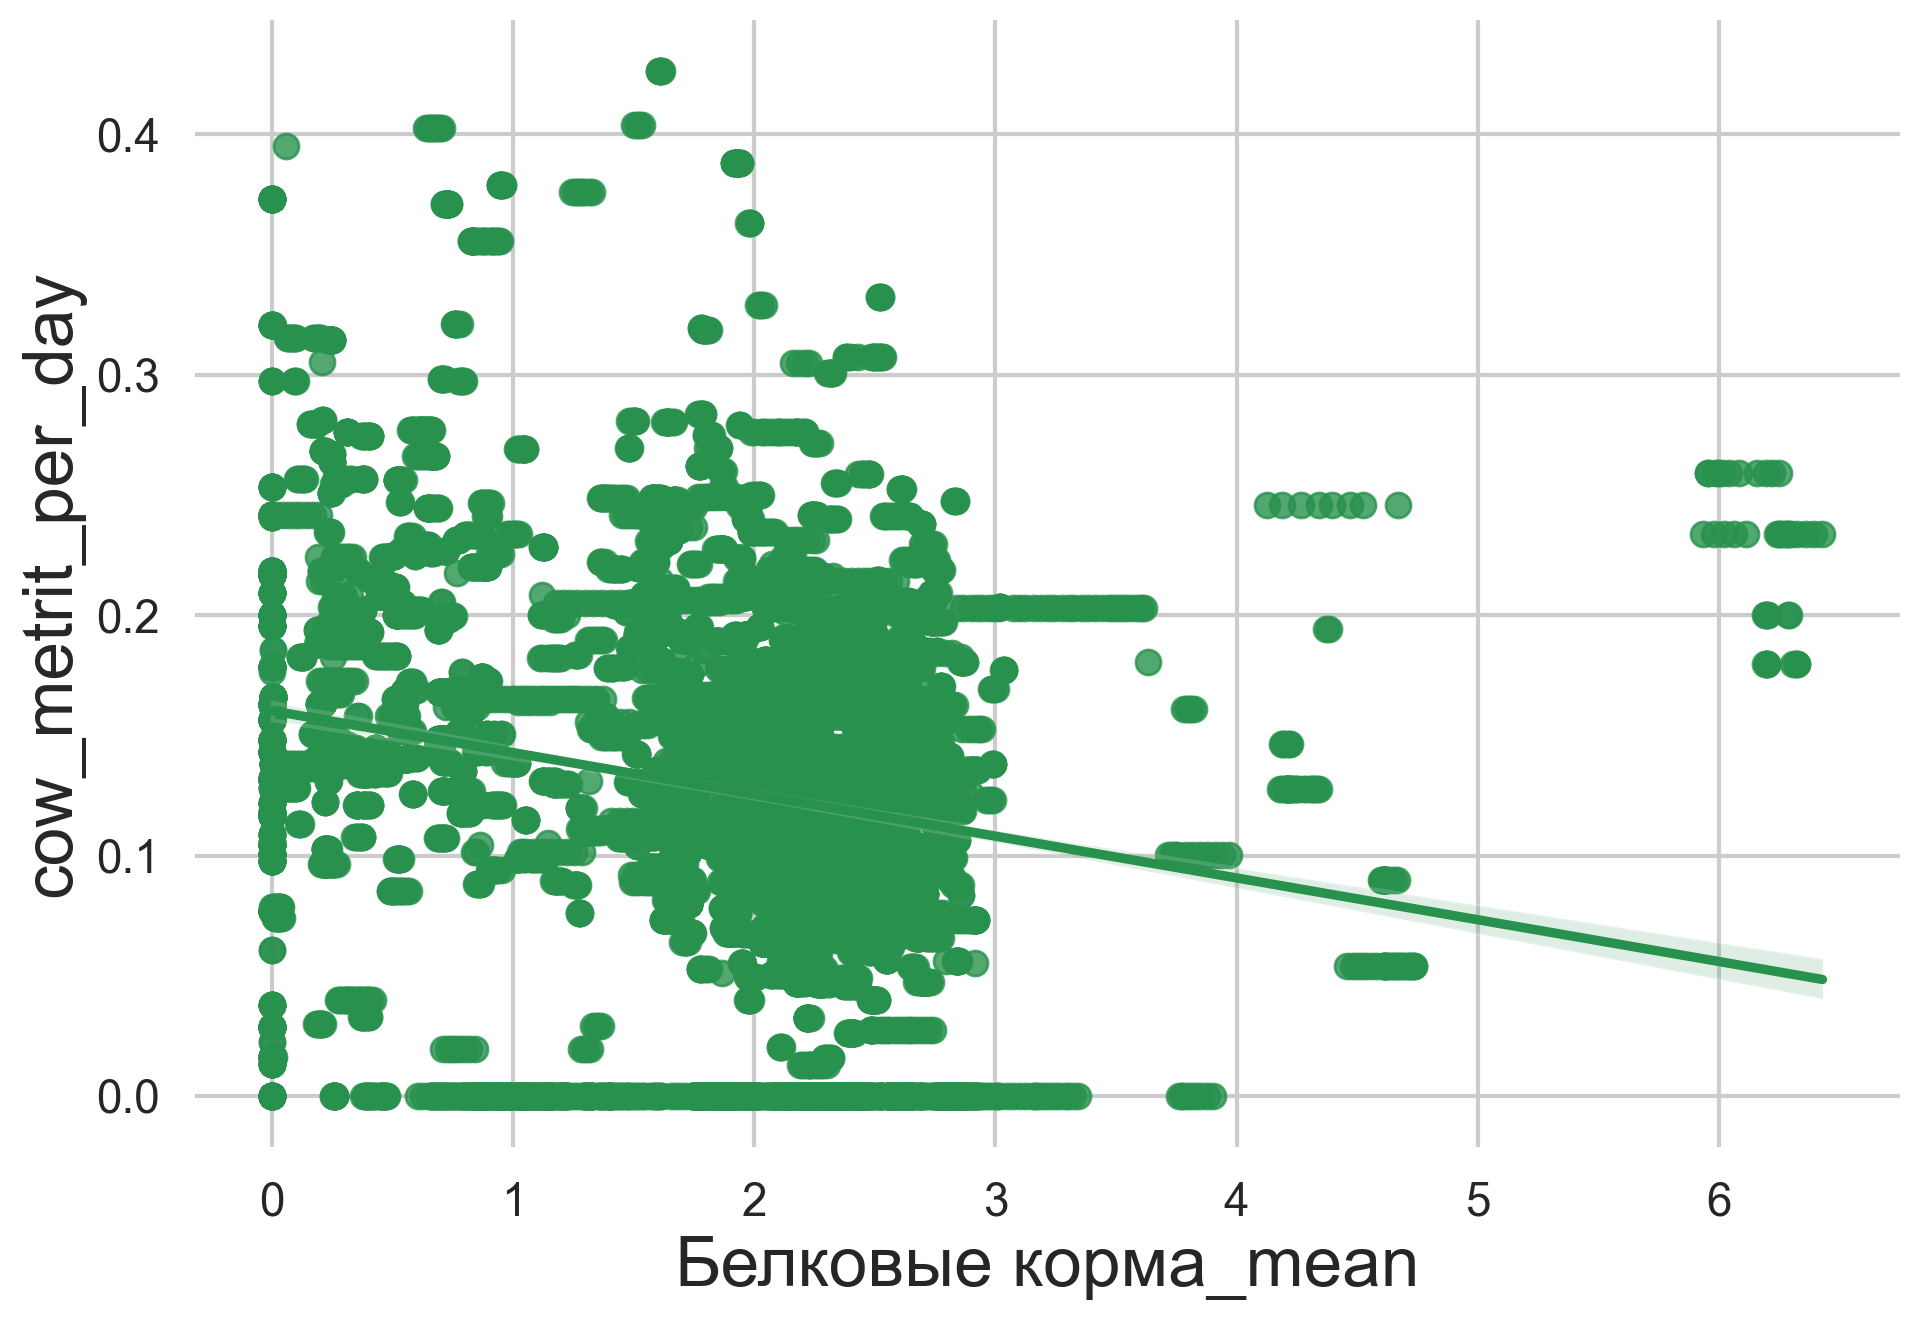

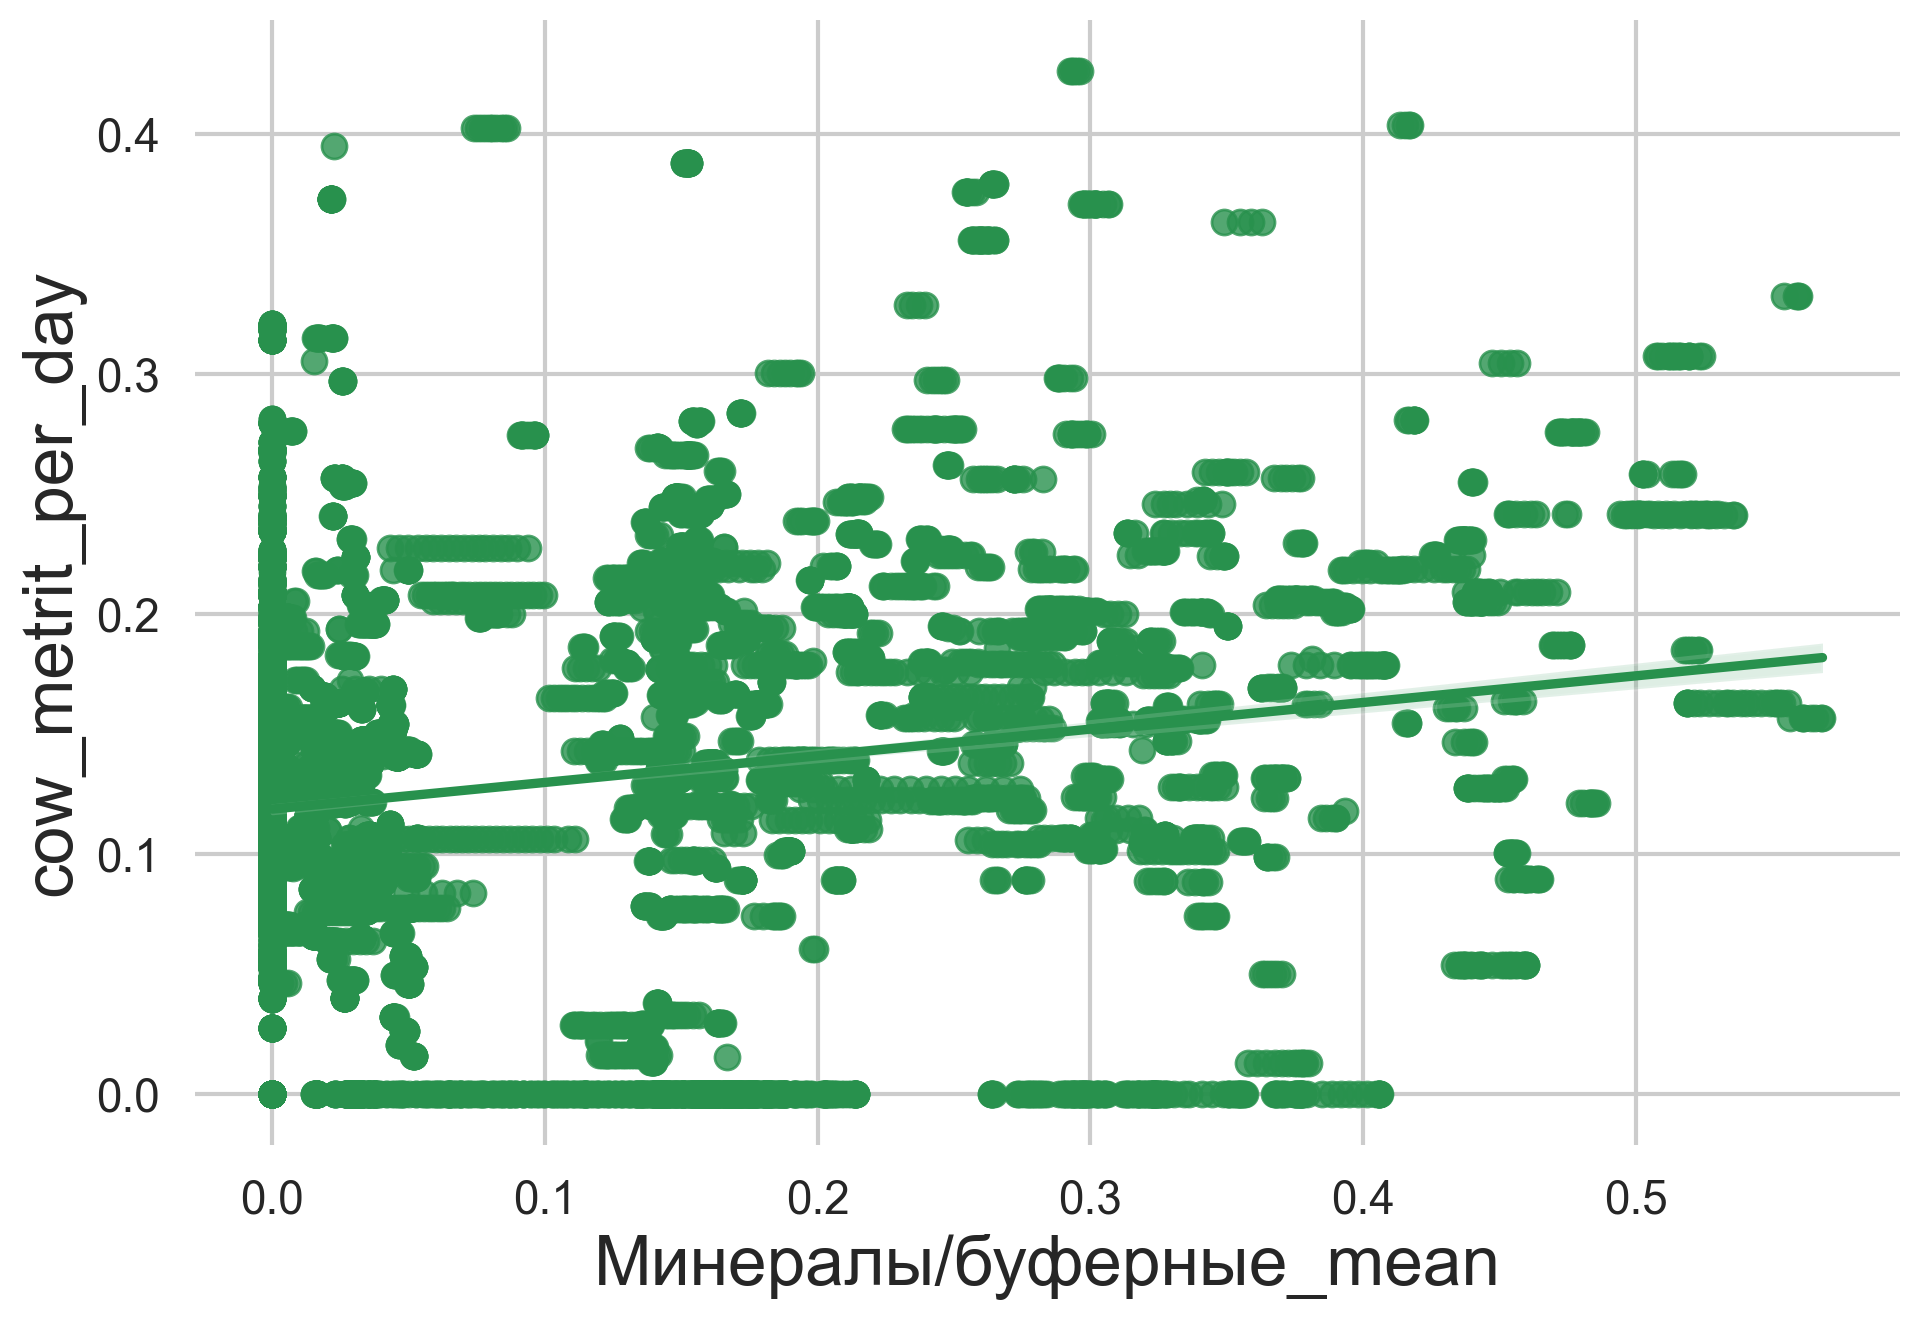

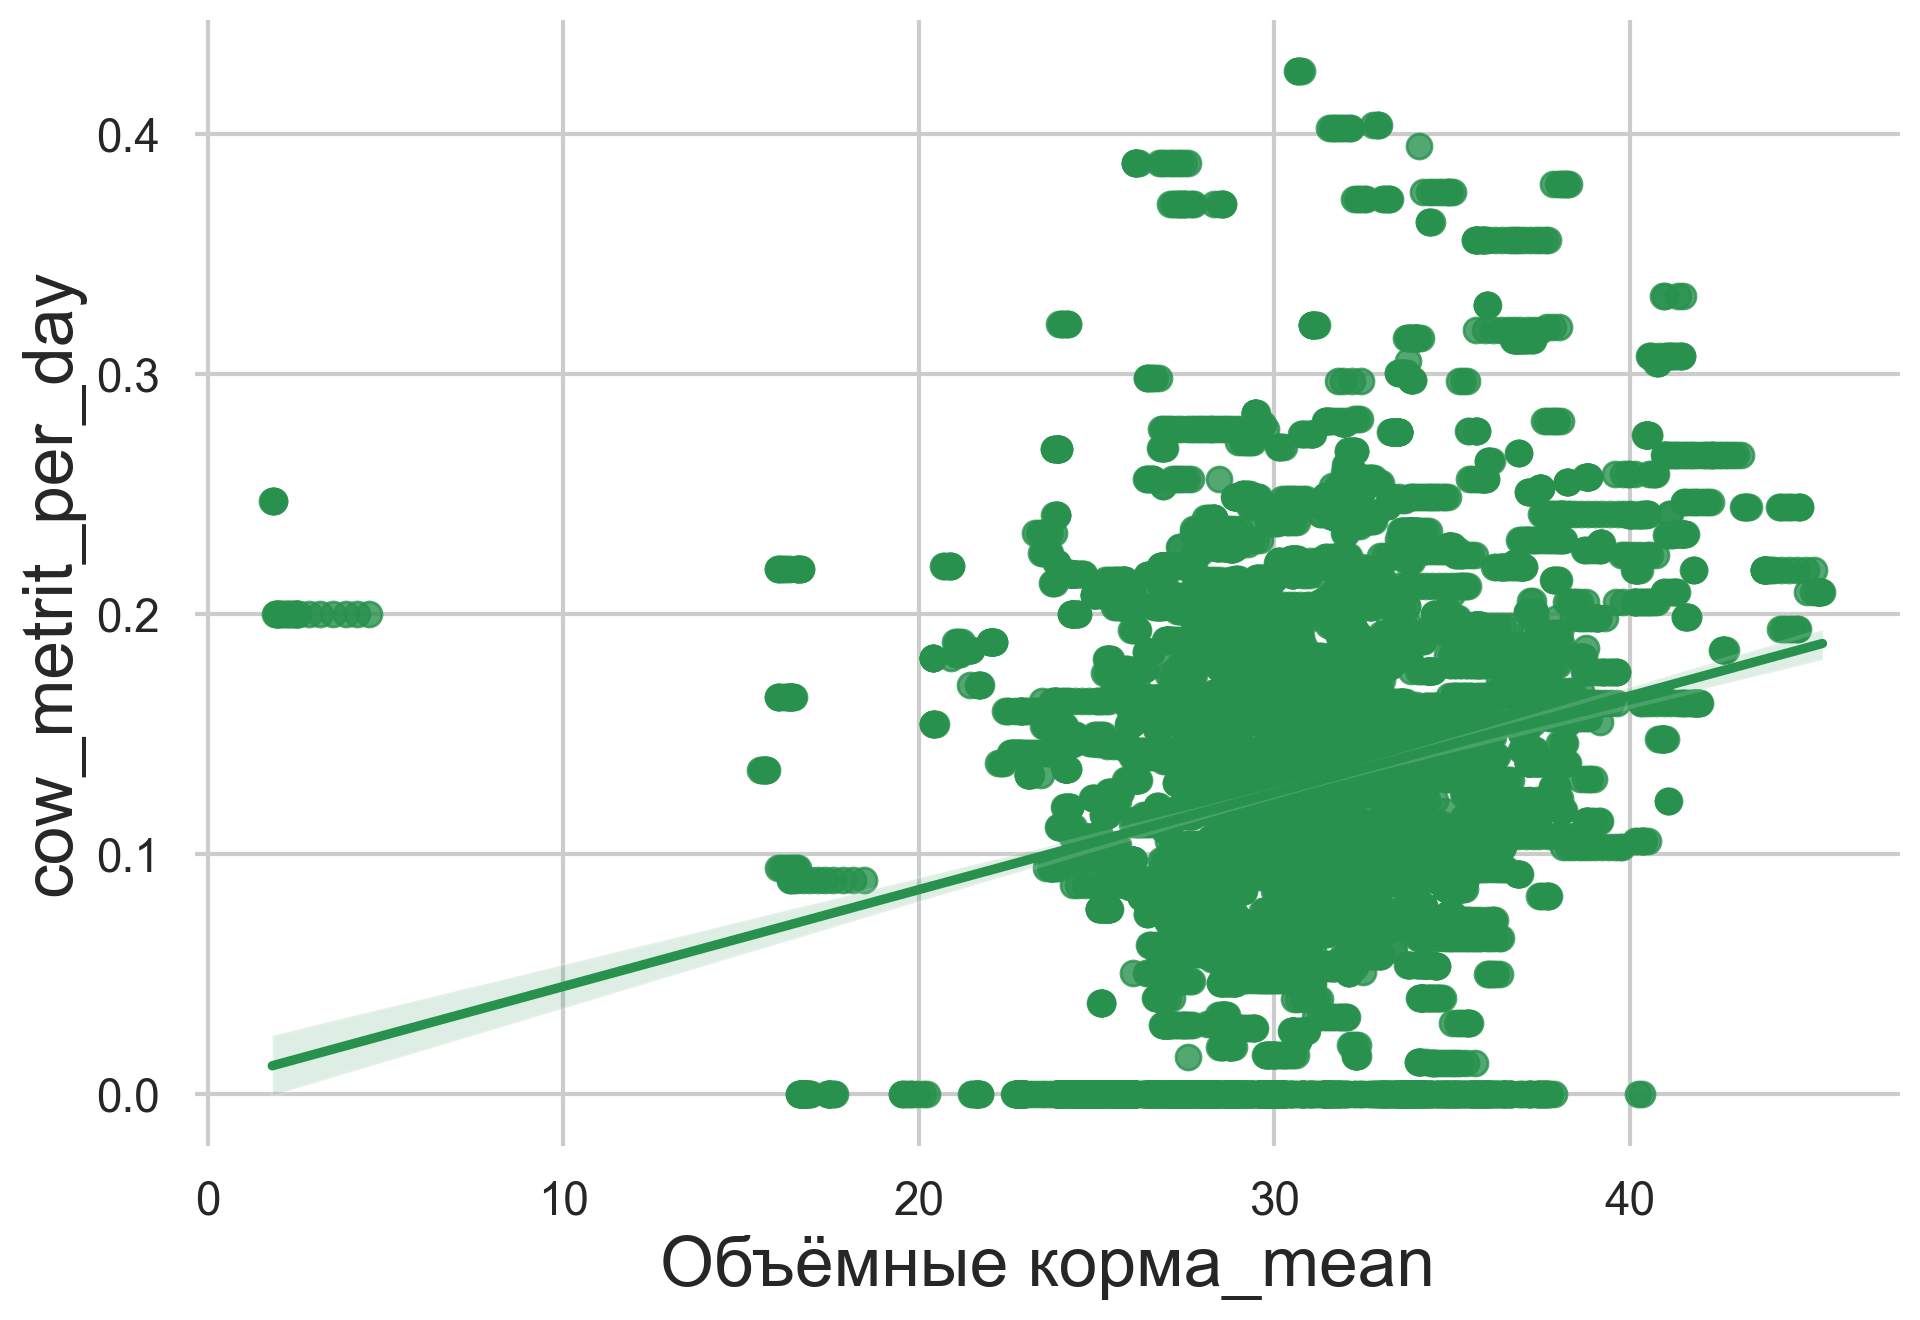

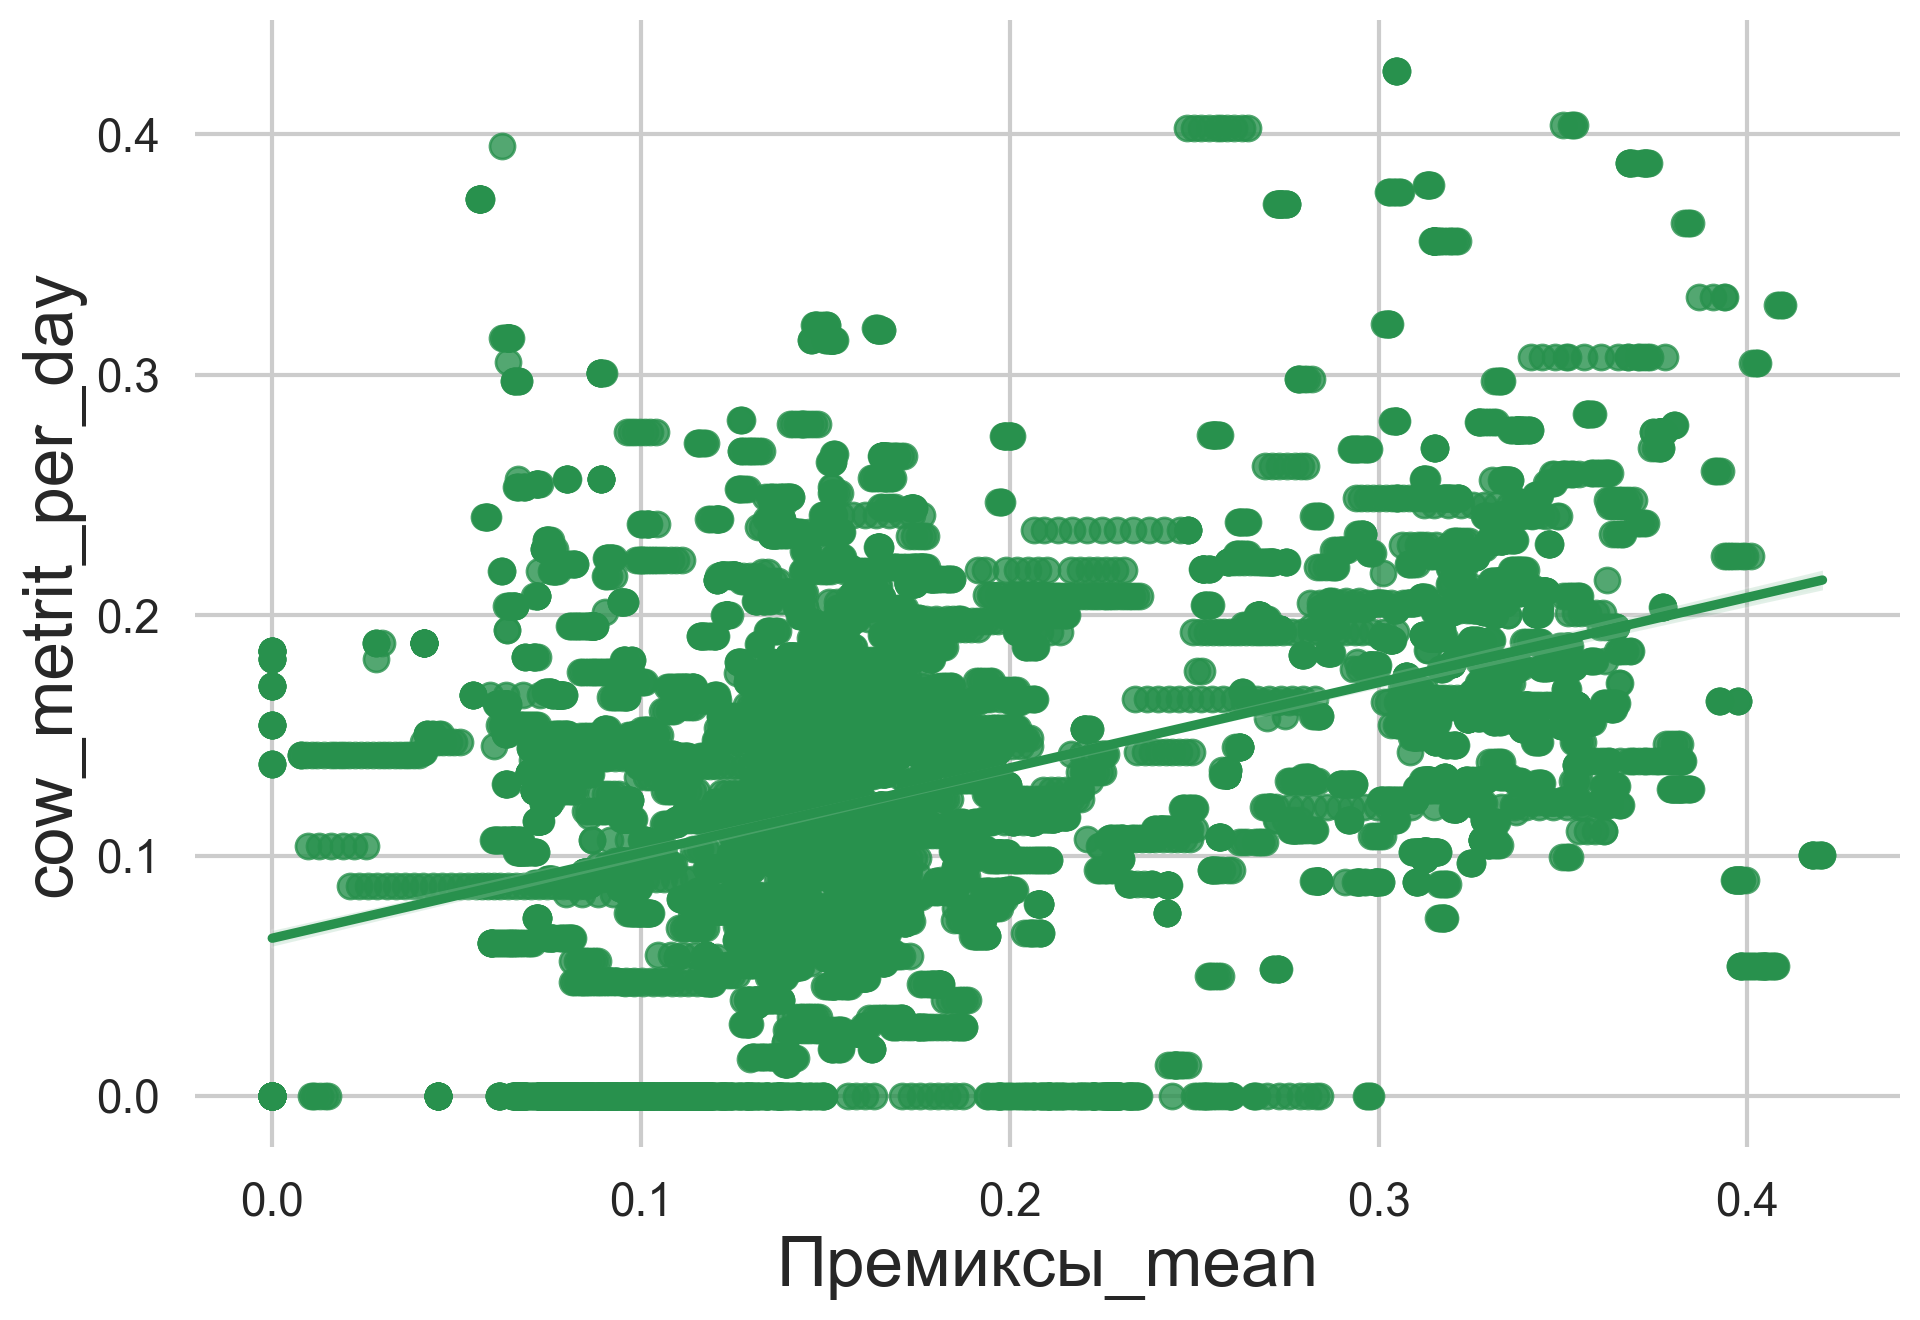

In [39]:
for col in num_cols:
    if col == 'time_trend':
        continue
    plt.subplots()
    sns.regplot(data=good_df, x=col, y='cow_metrit_per_day')

In [41]:
X = good_df[new_ration_cols].apply(pd.to_numeric, errors='coerce')
X.columns = X.columns.str.replace("_mean", "")

X = X.dropna(how='all')

corr = X.corr(method='pearson')

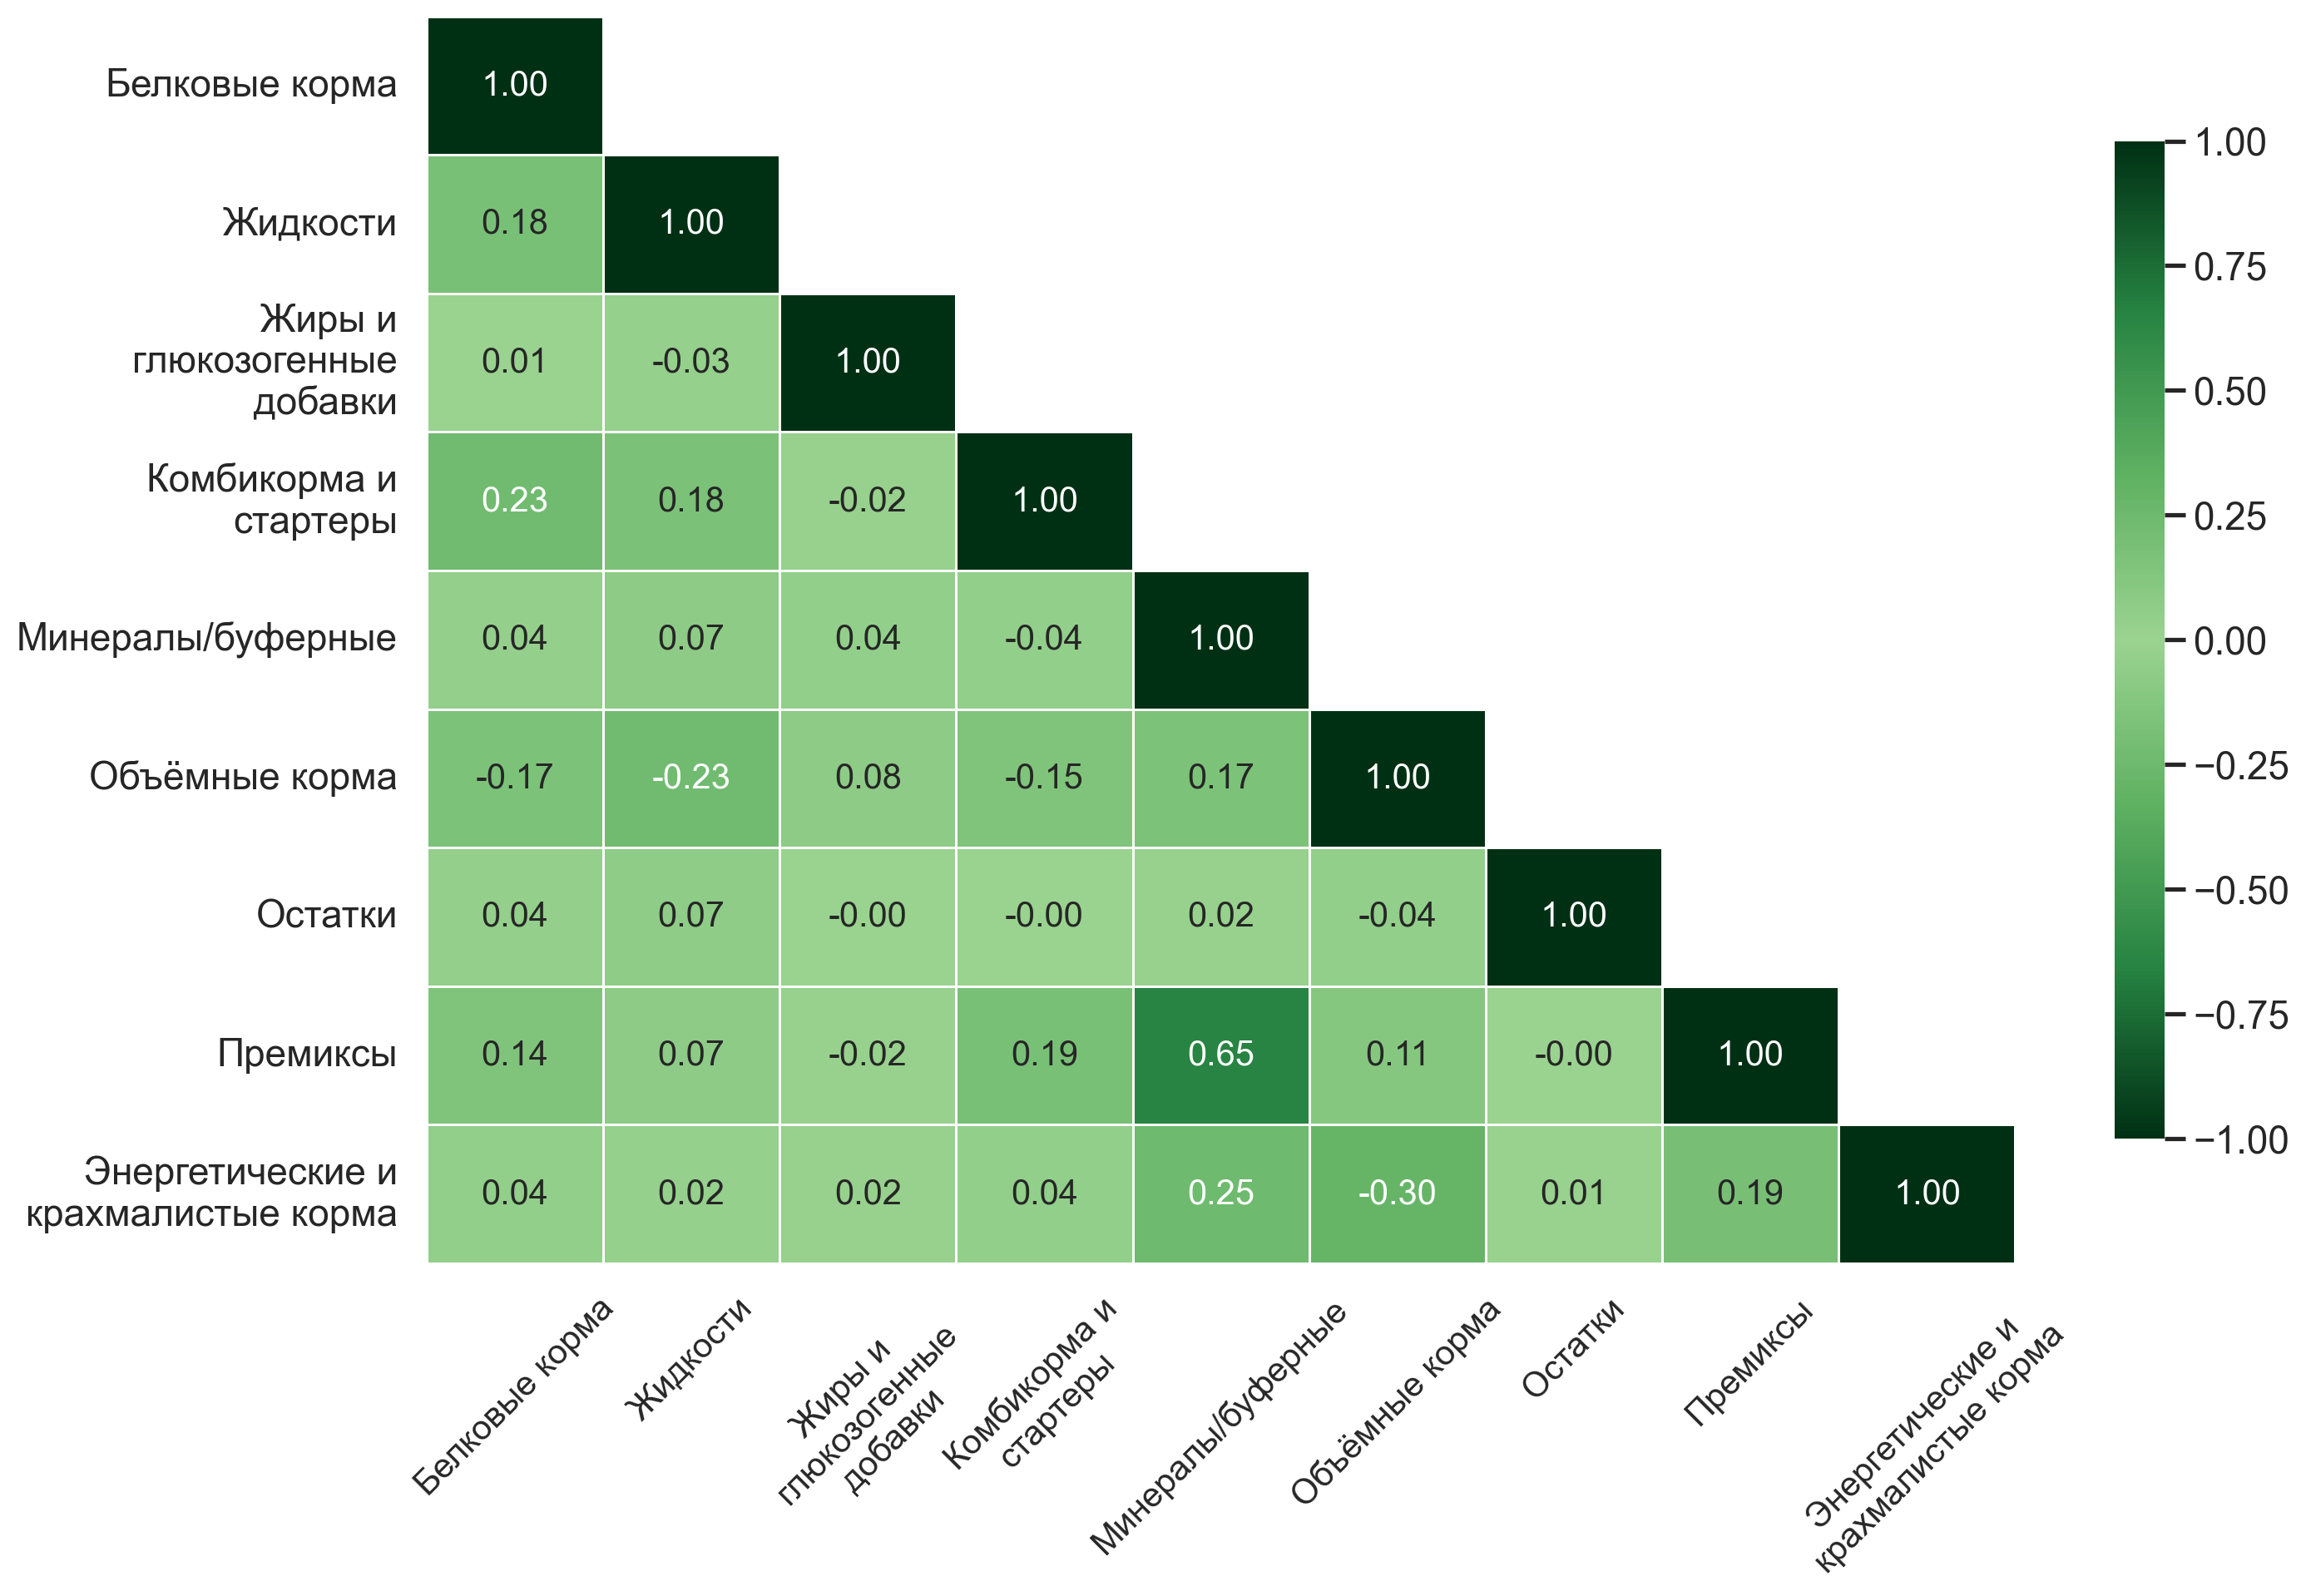

In [42]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import textwrap
custom_greens_sym = ["#003014", "#258241", "#5fb162", "#9ad390",
                     '#5fb162', '#258241', '#003014']
cmap = LinearSegmentedColormap.from_list("custom_green", custom_greens_sym)
def wrap_labels(labels, width=18):
    return ['\n'.join(textwrap.wrap(label, width)) for label in labels]

corr.index = wrap_labels(corr.index, width=18)
corr.columns = wrap_labels(corr.columns, width=18)
mask = corr.where(~np.triu(np.ones_like(corr, dtype=bool), k=1))
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
plt.figure(figsize=(15, 10))
sns.heatmap(
    mask,
    annot=True,
    cmap=cmap,
    norm=norm,
    fmt='.2f',
    annot_kws={"size": 15}, cbar_kws={"shrink": 0.8},
    linewidths=1, linecolor='white',
)
plt.xticks(rotation=45, fontsize=15)
plt.grid(False)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.show()

In [54]:
good_df["norm_diff"] = good_df["PracticalWeight"] - 40
good_df

,farm_name,date,cow_metrit_per_day,window_start_date,window_end_date,diff,TotalWeight,PracticalWeight,Белковые корма_mean,Жидкости_mean,Жиры и глюкозогенные добавки_mean,Комбикорма и стартеры_mean,Минералы/буферные_mean,Объёмные корма_mean,Остатки_mean,Премиксы_mean,Энергетические и крахмалистые корма_mean,new_overfed,region,morn_diff,norn_diff,norm_diff
0,ЖК Авангард,2023-05-23,0.142857,2023-03-24,2023-05-22,-16.375221,52.209302,35.834081,1.701370,0.060922,0.0,0.366876,0.245967,33.070578,0.0,0.234491,0.328861,False,Рязань,-4.165919,-2.165919,-4.165919
1,ЖК Авангард,2023-05-24,0.142857,2023-03-25,2023-05-23,-15.393005,51.440217,36.047212,1.698964,0.059728,0.0,0.372589,0.246038,33.060957,0.0,0.236618,0.330739,False,Рязань,-3.952788,-1.952788,-3.952788
2,ЖК Авангард,2023-05-25,0.142857,2023-03-26,2023-05-24,-14.533044,50.879121,36.346077,1.695586,0.058579,0.0,0.377218,0.245740,33.058741,0.0,0.238579,0.331988,False,Рязань,-3.653923,-1.653923,-3.653923
3,ЖК Авангард,2023-05-26,0.142857,2023-03-27,2023-05-25,-13.798143,50.027473,36.229330,1.695219,0.057474,0.0,0.381444,0.245502,33.059961,0.0,0.240477,0.332764,False,Рязань,-3.770670,-1.770670,-3.770670
4,ЖК Авангард,2023-05-27,0.142857,2023-03-28,2023-05-26,-13.606687,50.335196,36.728508,1.692787,0.056409,0.0,0.385640,0.245272,33.061400,0.0,0.242305,0.333037,False,Рязань,-3.271492,-1.271492,-3.271492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11002,МТФ Щучье,2025-06-08,0.119565,2025-04-09,2025-06-07,5.798198,21.318681,27.116879,1.283420,0.000000,0.0,0.000000,0.000000,24.123020,0.0,0.249906,0.000000,False,Воронеж,-12.883121,-10.883121,-12.883121
11003,МТФ Щучье,2025-06-09,0.119565,2025-04-10,2025-06-08,6.300466,20.863636,27.164102,1.291621,0.000000,0.0,0.000000,0.000000,24.074737,0.0,0.250192,0.000000,False,Воронеж,-12.835898,-10.835898,-12.835898
11004,МТФ Щучье,2025-07-29,0.168142,2025-05-30,2025-07-28,-2.250625,27.791667,25.541042,1.629038,0.000000,0.0,0.000000,0.000000,25.545218,0.0,0.263112,0.000000,False,Воронеж,-14.458958,-12.458958,-14.458958
11005,МТФ Щучье,2025-07-30,0.168142,2025-05-31,2025-07-29,-2.250625,27.791667,25.541042,1.646821,0.000000,0.0,0.000000,0.000000,25.486669,0.0,0.262999,0.000000,False,Воронеж,-14.458958,-12.458958,-14.458958
